In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/content/covid_19_clean_complete (1).csv")
df.head()



,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [30]:
df.shape

(49068, 10)

In [31]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [32]:
df[['Confirmed','Deaths','Recovered','Active']].describe()

,Confirmed,Deaths,Recovered,Active
count,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


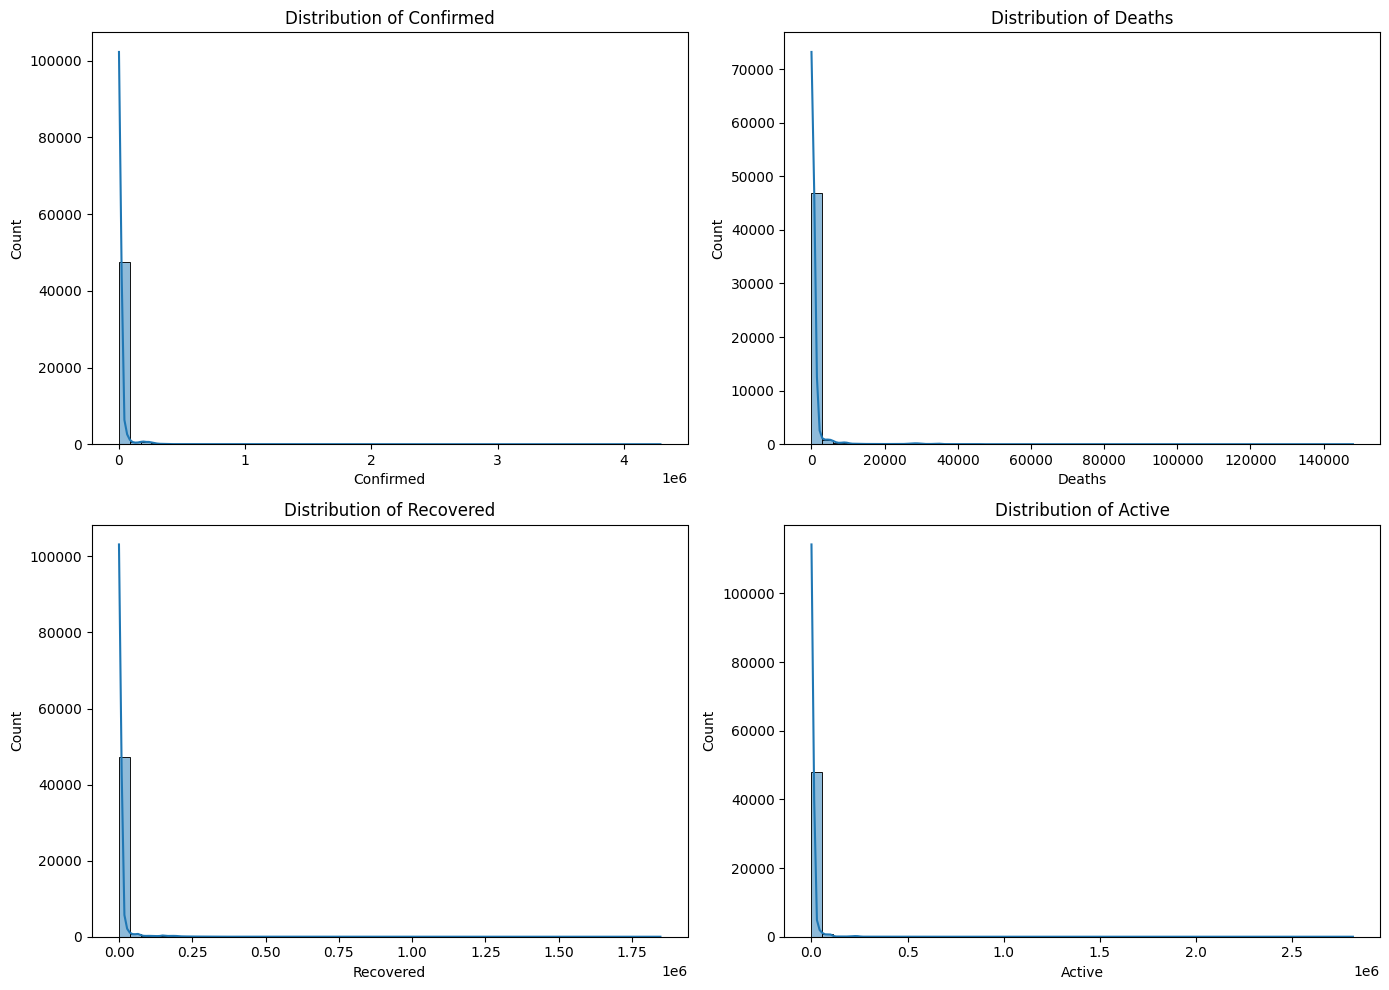

In [33]:
cols = ['Confirmed','Deaths','Recovered','Active']

plt.figure(figsize=(14,10))
for i, col in enumerate(cols, 1):
    plt.subplot(2,2,i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


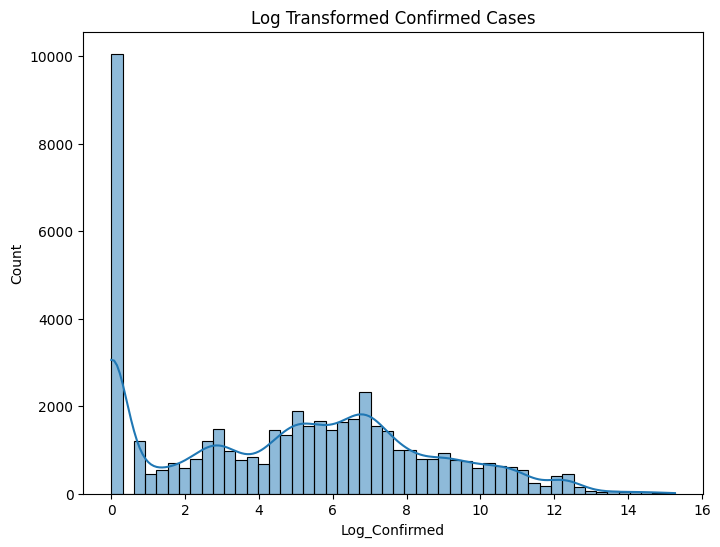

In [34]:
#Log Transformation (Handling Skewed Data)

df['Log_Confirmed'] = np.log1p(df['Confirmed'])

plt.figure(figsize=(8,6))
sns.histplot(df['Log_Confirmed'], bins=50, kde=True)
plt.title("Log Transformed Confirmed Cases")
plt.show()


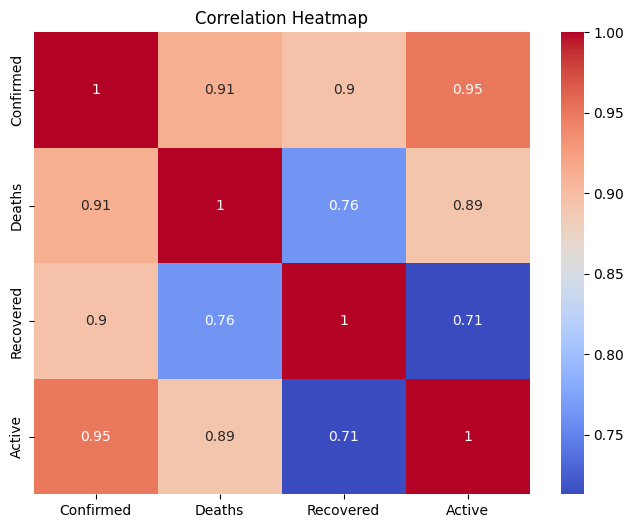

In [35]:
#Correlation Analysis (Heatmap)
plt.figure(figsize=(8,6))
sns.heatmap(df[['Confirmed','Deaths','Recovered','Active']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [36]:
#Recovery Rate & Mortality Rate (Feature Engineering)

df['Recovery_Rate'] = (df['Recovered'] / df['Confirmed']) * 100
df['Mortality_Rate'] = (df['Deaths'] / df['Confirmed']) * 100

df[['Recovery_Rate','Mortality_Rate']].describe()


,Recovery_Rate,Mortality_Rate
count,39009.000000,39009.000000
mean,47.530670,2.799382
std,37.511083,4.386398
min,0.000000,0.000000
25%,8.333333,0.000000
50%,46.100247,1.369863
75%,86.938776,3.856017
max,100.187091,100.000000


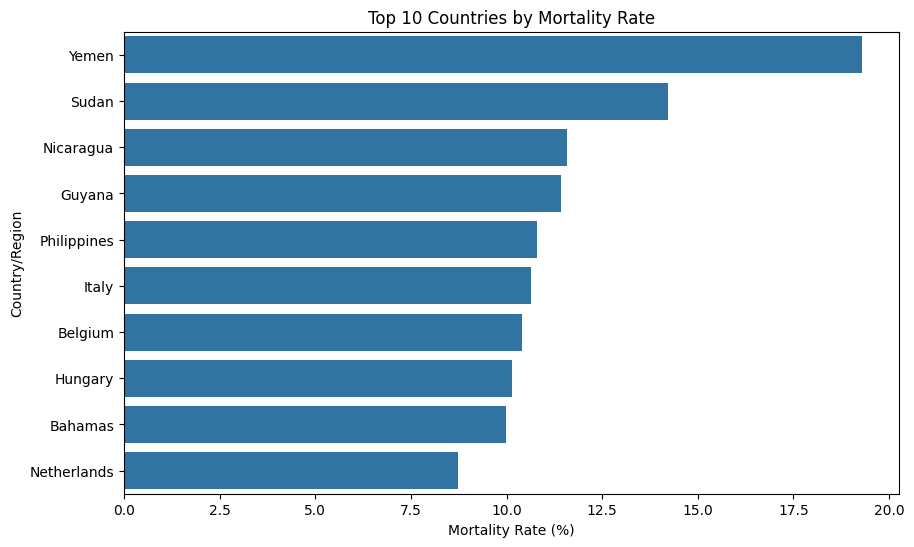

In [37]:
#Country-wise Mortality Comparison (Top 10)
mortality = df.groupby('Country/Region')['Mortality_Rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=mortality.values, y=mortality.index)
plt.title("Top 10 Countries by Mortality Rate")
plt.xlabel("Mortality Rate (%)")
plt.show()


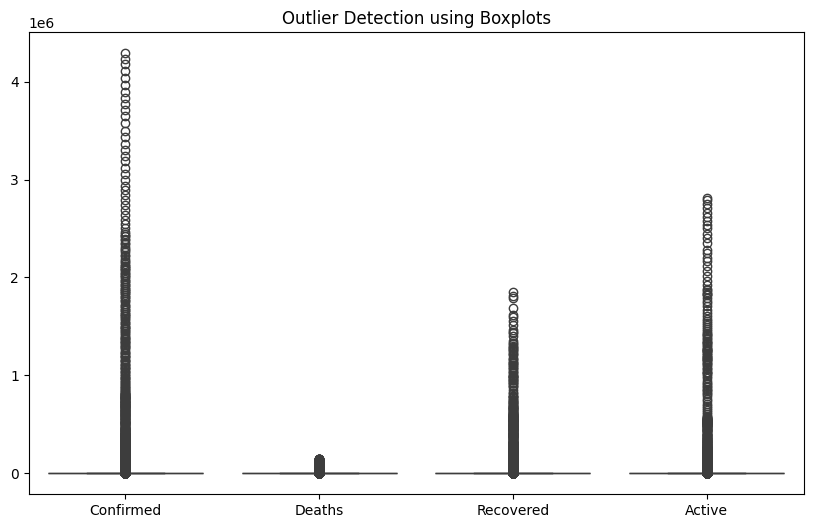

In [38]:
#Boxplot Analysis (Outlier Detection)
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Confirmed','Deaths','Recovered','Active']])
plt.title("Outlier Detection using Boxplots")
plt.show()


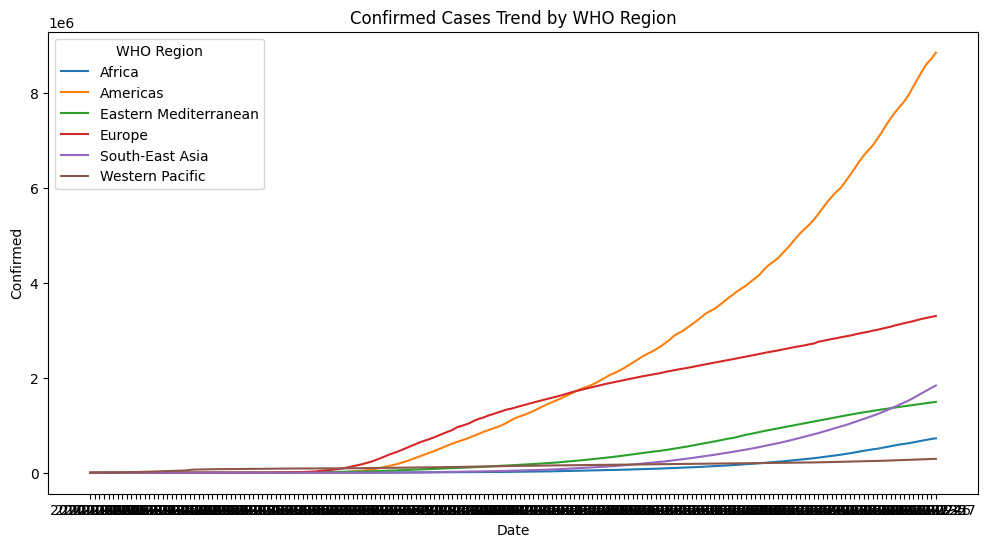

In [39]:
#WHO Region-wise Trend Over Time
region_trend = df.groupby(['Date','WHO Region'])['Confirmed'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=region_trend, x='Date', y='Confirmed', hue='WHO Region')
plt.title("Confirmed Cases Trend by WHO Region")
plt.show()


In [40]:
df = df.drop("Province/State", axis=1)

In [41]:
skewness = df.skew(numeric_only=True)
skewness

,0
Lat,-0.573083
Long,-0.013375
Confirmed,18.567593
Deaths,13.740139
Recovered,16.380959
Active,22.306956
Log_Confirmed,0.162066
Recovery_Rate,0.064863
Mortality_Rate,6.205437


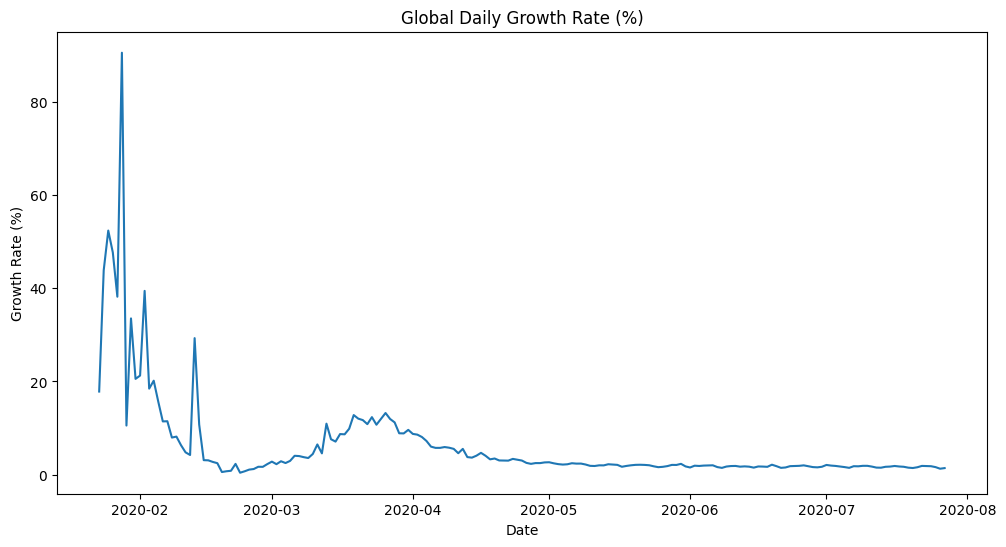

In [42]:
#Growth Rate Analysis (Time-Series)
global_daily['Daily_Growth_Rate'] = global_daily['Confirmed'].pct_change() * 100

plt.figure(figsize=(12,6))
plt.plot(global_daily.index, global_daily['Daily_Growth_Rate'])
plt.title("Global Daily Growth Rate (%)")
plt.ylabel("Growth Rate (%)")
plt.xlabel("Date")
plt.show()


/tmp/ipython-input-2818346628.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M', on='Date')[['Confirmed','Deaths','Recovered']].sum()


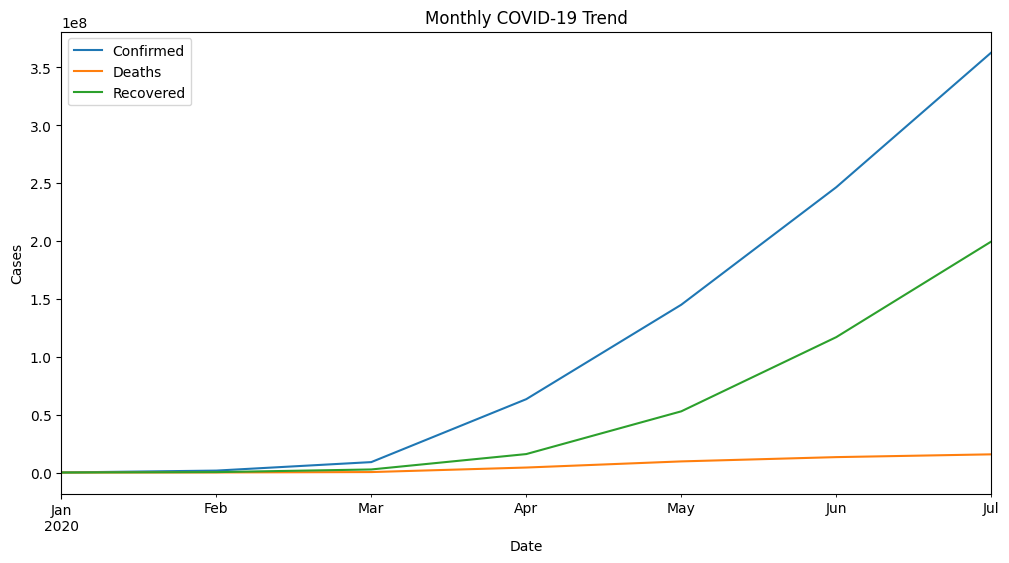

In [55]:
#Monthly Aggregation (Trend Smoothing)
monthly_data = df.resample('M', on='Date')[['Confirmed','Deaths','Recovered']].sum()

monthly_data.plot(figsize=(12,6))
plt.title("Monthly COVID-19 Trend")
plt.ylabel("Cases")
plt.show()


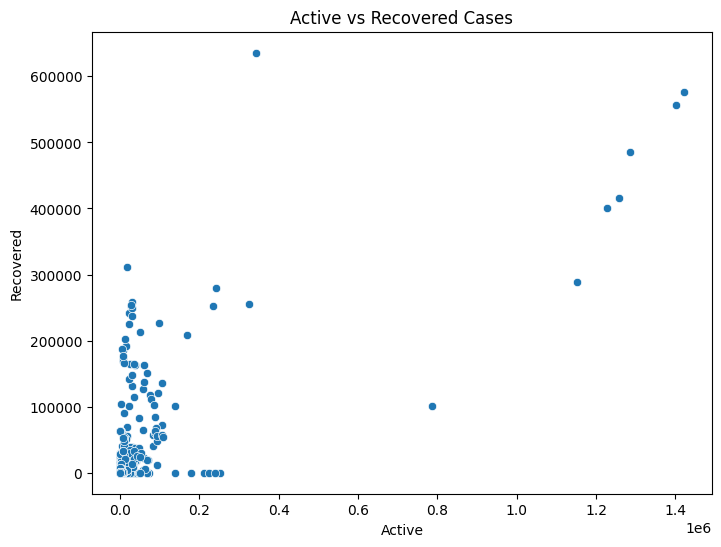

In [54]:
#Active vs Recovered Analysis
plt.figure(figsize=(8,6))
sns.scatterplot(data=df.sample(3000), x='Active', y='Recovered')
plt.title("Active vs Recovered Cases")
plt.show()


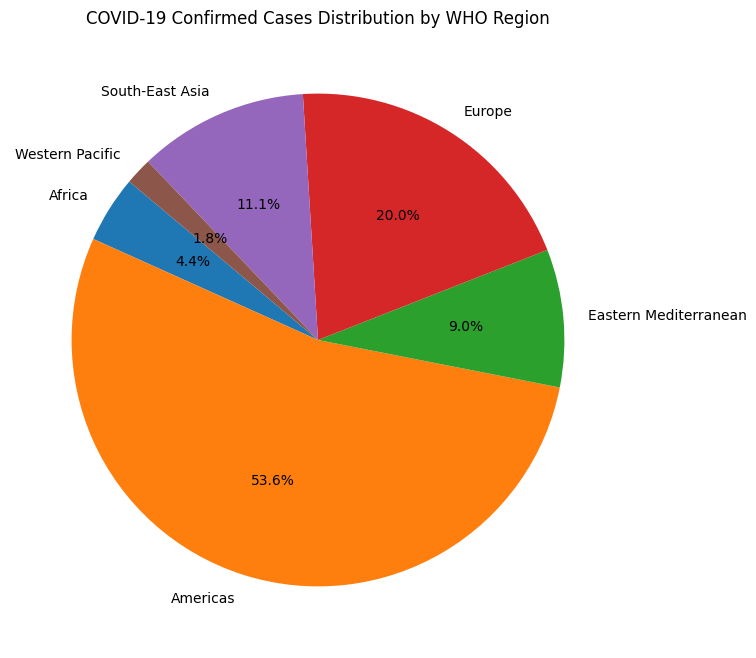

In [53]:
latest_data = df[df['Date'] == df['Date'].max()]
region_cases = latest_data.groupby("WHO Region")["Confirmed"].sum()


plt.figure(figsize=(8,8))
plt.pie(region_cases, labels=region_cases.index, autopct='%1.1f%%', startangle=140)
plt.title("COVID-19 Confirmed Cases Distribution by WHO Region")
plt.show()


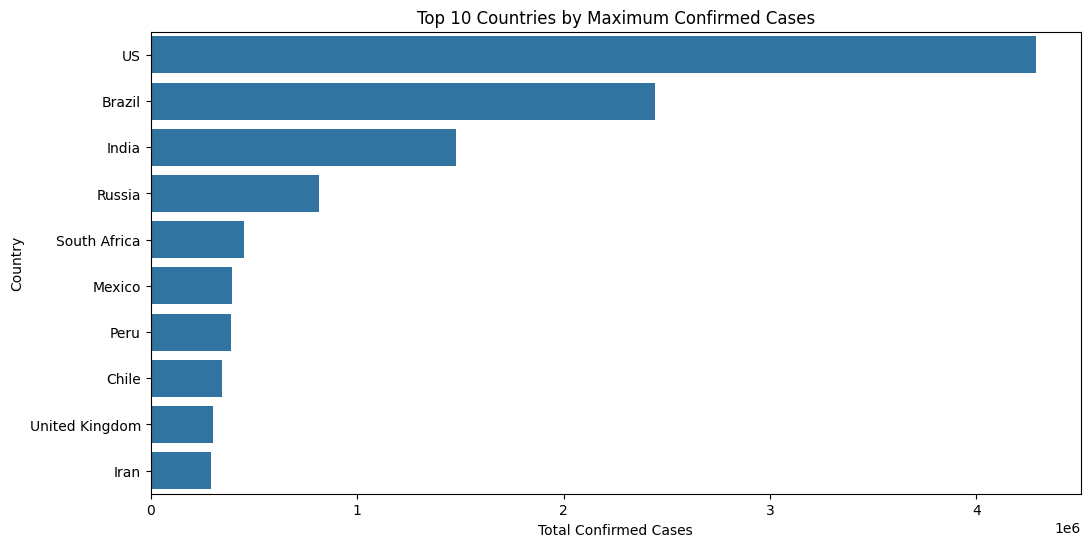

In [52]:
top10 = df.groupby("Country/Region")['Confirmed'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Countries by Maximum Confirmed Cases")
plt.xlabel("Total Confirmed Cases")
plt.ylabel("Country")
plt.show()


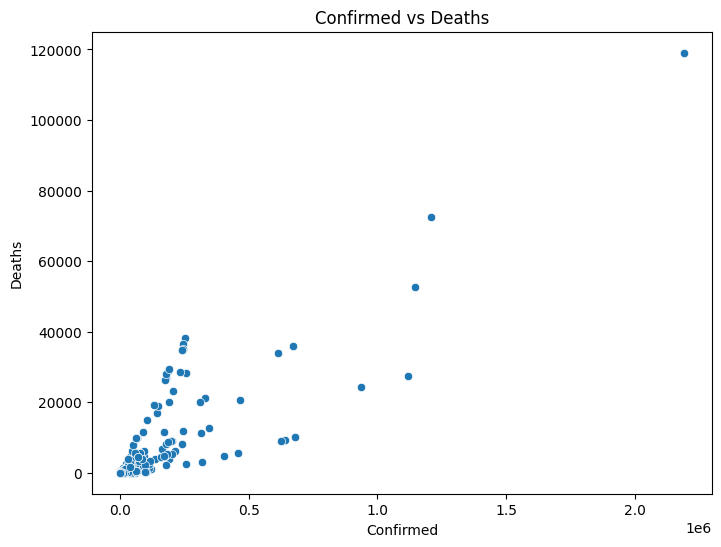

In [51]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df.sample(2000), x='Confirmed', y='Deaths')
plt.title("Confirmed vs Deaths")
plt.show()

In [50]:
#Pareto Analysis (80–20 Rule)
country_total = df.groupby('Country/Region')['Confirmed'].max().sort_values(ascending=False)
country_total.cumsum() / country_total.sum()


,Confirmed
Country/Region,
US,0.261854
Brazil,0.410924
India,0.501259
Russia,0.551105
South Africa,0.578725
...,...
Dominica,0.999997
Saint Kitts and Nevis,0.999998
Greenland,0.999999


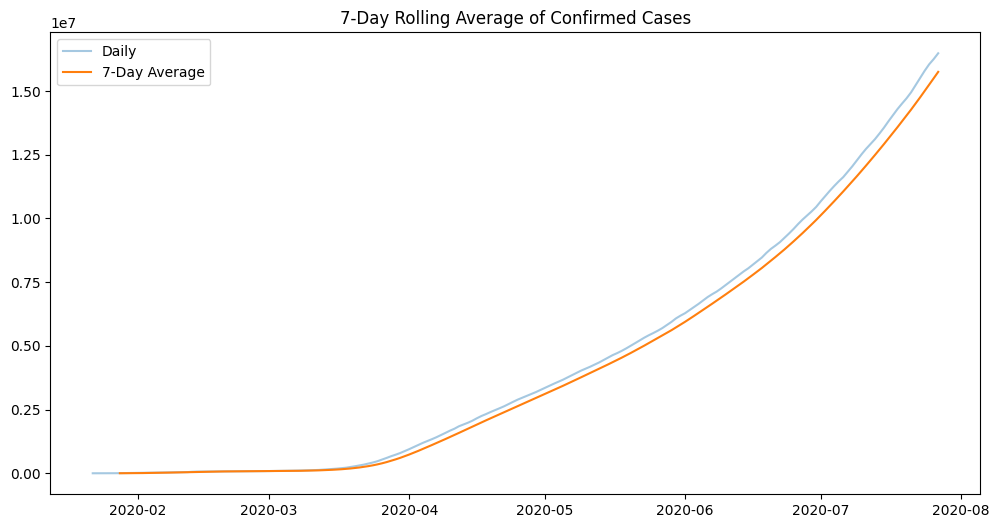

In [49]:
#Rolling Average (Smoothing Curves)
global_daily['Confirmed_7Day_Avg'] = global_daily['Confirmed'].rolling(7).mean()

plt.figure(figsize=(12,6))
plt.plot(global_daily.index, global_daily['Confirmed'], alpha=0.4, label='Daily')
plt.plot(global_daily.index, global_daily['Confirmed_7Day_Avg'], label='7-Day Average')
plt.legend()
plt.title("7-Day Rolling Average of Confirmed Cases")
plt.show()


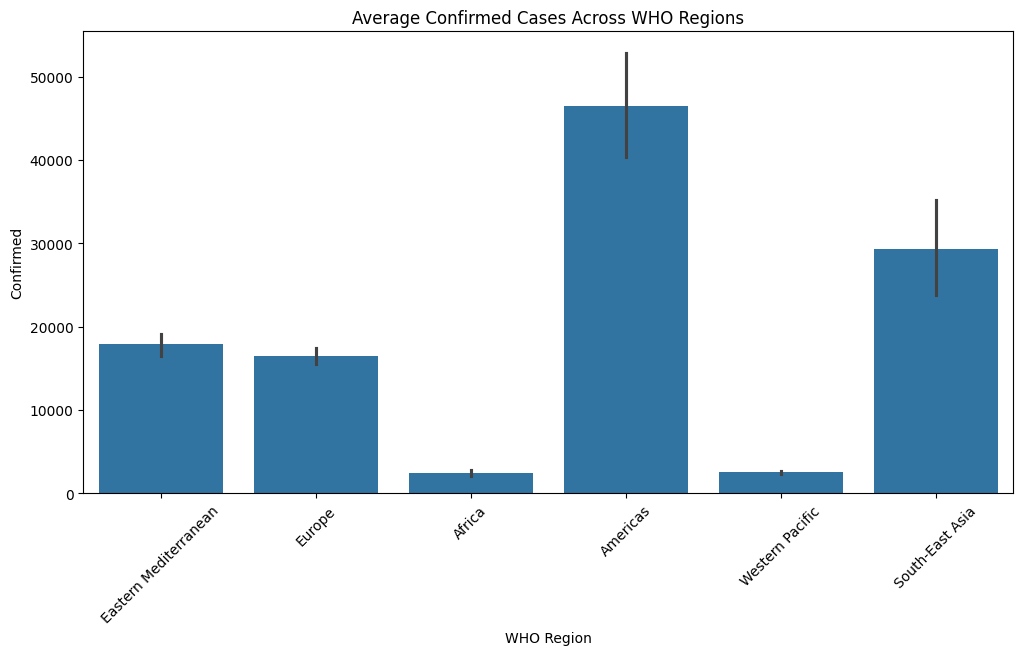

In [48]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='WHO Region', y='Confirmed', estimator='mean')
plt.title("Average Confirmed Cases Across WHO Regions")
plt.xticks(rotation=45)
plt.show()

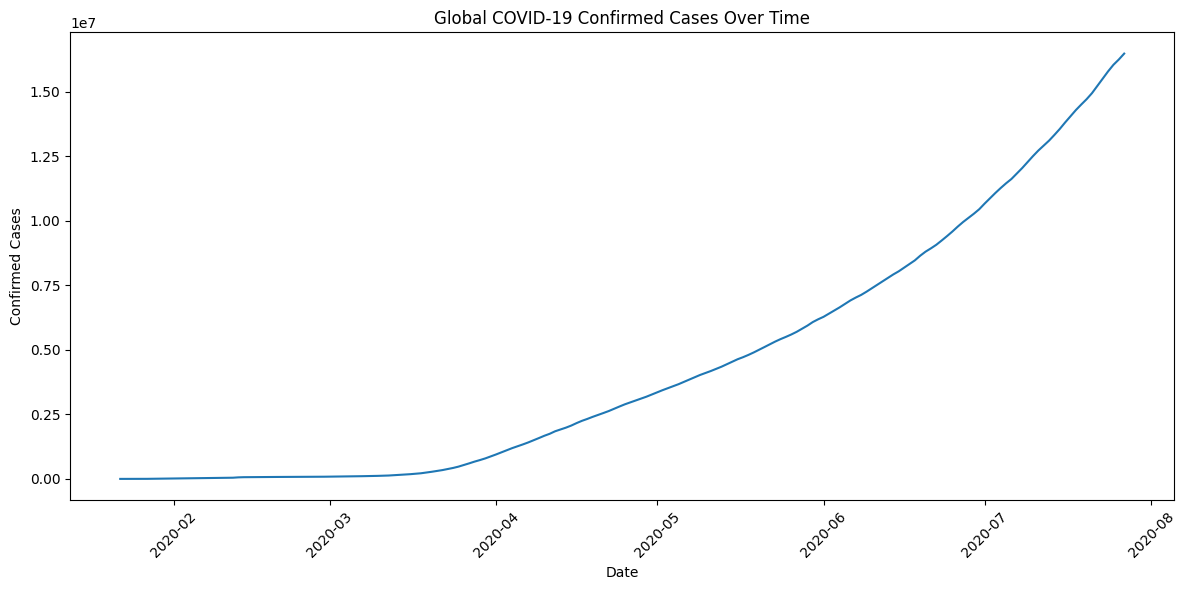

In [47]:
df['Date'] = pd.to_datetime(df['Date'])
global_daily = df.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum()

plt.figure(figsize=(12,6))
plt.plot(global_daily.index, global_daily['Confirmed'])
plt.title("Global COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

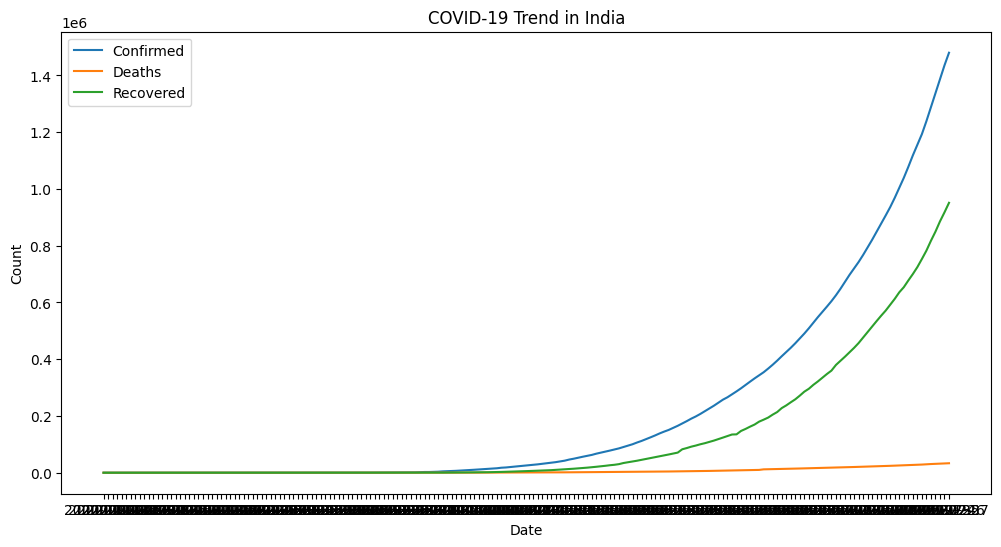

In [46]:
# COUNTRY-LEVEL TREND
# -----------------------------------------

country = "India"   # You can change this

country_df = df[df["Country/Region"] == country].groupby('Date')[['Confirmed','Deaths','Recovered']].sum()

plt.figure(figsize=(12,6))
plt.plot(country_df.index, country_df['Confirmed'], label='Confirmed')
plt.plot(country_df.index, country_df['Deaths'], label='Deaths')
plt.plot(country_df.index, country_df['Recovered'], label='Recovered')
plt.legend()
plt.title(f"COVID-19 Trend in {country}")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

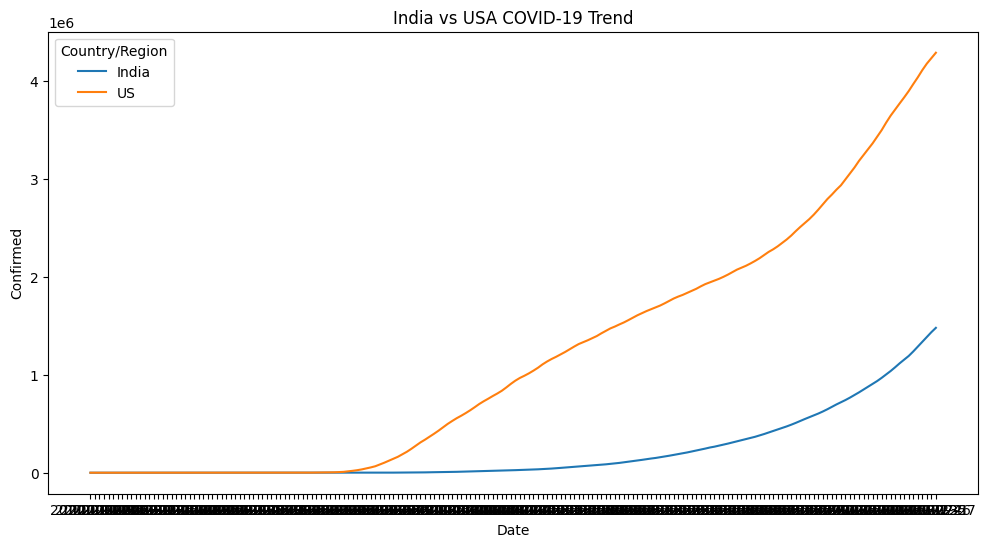

In [45]:
#Comparative Country Analysis (India vs USA)
compare = df[df['Country/Region'].isin(['India','US'])].groupby(['Date','Country/Region'])['Confirmed'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=compare, x='Date', y='Confirmed', hue='Country/Region')
plt.title("India vs USA COVID-19 Trend")
plt.show()
